In [28]:
import pandas as pd
import os

# 1. Set paths
folder_path = "data scraping"
model_ready_path = "model_ready"
os.makedirs(model_ready_path, exist_ok=True)

file_name = "tm_big5_player_market_values_history_PROGRESS.csv"
full_path = os.path.join(folder_path, file_name)

# 2. Load the headless CSV and assign names
column_names = ['player_url', 'date', 'player_market_value_euro', 'squad', 'age']
df = pd.read_csv(full_path, names=column_names, low_memory=False)

# 3. Clean and Format
# First, convert to datetime to use pandas date tools
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- THE UPDATE: REMOVE HOURS AND MINUTES ---
# This converts '2019-06-13 00:00:00' to just '2019-06-13'
df['date'] = df['date'].dt.date

df['player_market_value_euro'] = pd.to_numeric(df['player_market_value_euro'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 4. Filter for your project scope (2019-2024)
df = df.dropna(subset=['date', 'player_market_value_euro'])

# 5. Final Key Cleanup for Merging
df['player_url'] = df['player_url'].str.strip().str.rstrip('/')

print("Transfermarkt base data prepared in memory (no intermediate file saved).")
print(df.head())

Transfermarkt base data prepared in memory (no intermediate file saved).
                                          player_url        date  \
0  https://www.transfermarkt.com/ederson/profil/s...  2019-06-13   
1  https://www.transfermarkt.com/ederson/profil/s...  2019-12-10   
2  https://www.transfermarkt.com/ederson/profil/s...  2020-04-08   
3  https://www.transfermarkt.com/ederson/profil/s...  2020-10-13   
4  https://www.transfermarkt.com/ederson/profil/s...  2021-03-18   

   player_market_value_euro            squad  age  
0                70000000.0  Manchester City   25  
1                70000000.0  Manchester City   26  
2                56000000.0  Manchester City   26  
3                56000000.0  Manchester City   27  
4                56000000.0  Manchester City   27  


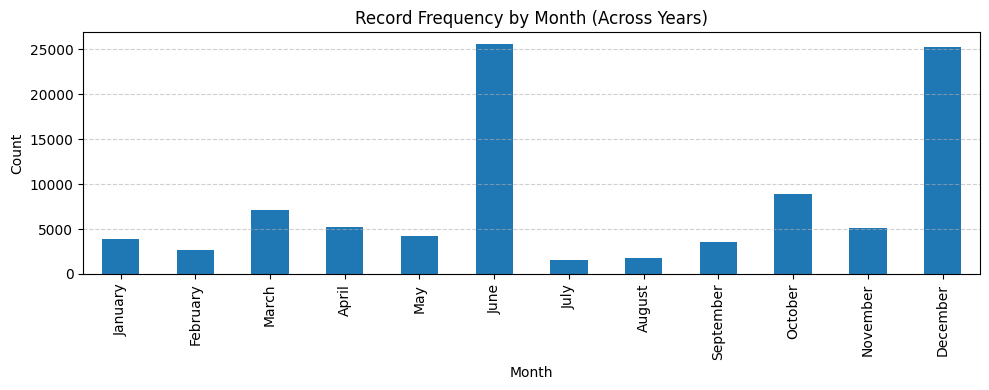

In [29]:
# Plot the frequency of records by month (ignoring year and day)

# Extract month name and count across all years
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['month'] = pd.to_datetime(df['date']).dt.month_name()
month_counts = df['month'].value_counts().reindex(month_order).fillna(0)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
month_counts.plot(kind='bar', ax=ax, color='tab:blue')
ax.set_title('Record Frequency by Month (Across Years)')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.grid(axis='y', linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show();

In [30]:
import pandas as pd
import numpy as np
import os

# 1. Use in-memory cleaned Transfermarkt dataframe from previous cell
if 'df' not in globals():
    raise RuntimeError("Run cell 1 first to prepare Transfermarkt data.")

df_tm_work = df.copy()
df_tm_work['date'] = pd.to_datetime(df_tm_work['date'])

# 2. Assigning the Season End Year
# Dates from Oct 2021 through Sep 2022 all count toward the '2022' season.
def assign_season_end(row):
    if row.month >= 10:
        return row.year + 1  # Oct-Dec 2021 belongs to Season 2022
    else:
        return row.year      # Jan-Sep 2022 belongs to Season 2022

df_tm_work['season_end_year'] = df_tm_work['date'].apply(assign_season_end)

# 3. Hierarchical Selection Function
def get_prioritized_value(group):
    # Method 1: June of the season year
    m1 = group[group['date'].dt.month == 6]
    if not m1.empty:
        return pd.Series([m1['player_market_value_euro'].mean(), "Method 1: June"])

    # Method 2: Jul - Sep of the season year
    m2 = group[group['date'].dt.month.isin([7, 8, 9])]
    if not m2.empty:
        return pd.Series([m2['player_market_value_euro'].mean(), "Method 2: Jul-Sep"])

    # Method 3: April - May of the season year
    m3 = group[group['date'].dt.month.isin([4, 5])]
    if not m3.empty:
        return pd.Series([m3.sort_values('date')['player_market_value_euro'].iloc[-1], "Method 3: Apr-May"])

    # Method 4: Oct (Prev Year) - March (Season Year)
    m4 = group[group['date'].dt.month.isin([10, 11, 12, 1, 2, 3])]
    if not m4.empty:
        return pd.Series([m4['player_market_value_euro'].mean(), "Method 4: Oct-Mar"])

    return pd.Series([np.nan, "No Data Found"])

# 4. Apply Logic
target_df = df_tm_work.groupby(['player_url', 'season_end_year']).apply(get_prioritized_value).reset_index()
target_df.columns = ['player_url', 'season_end_year', 'target_market_value', 'method']

# 5. Clean up
target_df = target_df.dropna(subset=['target_market_value'])

# 6. Method Count by Years
method_summary = target_df.groupby(['season_end_year', 'method']).size().unstack(fill_value=0)
print("--- Method Count by Season End Year ---")
print(method_summary)

# Save only the final Transfermarkt-ready file
tm_ready_file = os.path.join(model_ready_path, "tm_ready_to_merge.csv")
target_df.to_csv(tm_ready_file, index=False)
print(f"Saved Transfermarkt ready file: {tm_ready_file}")

--- Method Count by Season End Year ---
method           Method 1: June  Method 2: Jul-Sep  Method 3: Apr-May  \
season_end_year                                                         
2019                       4131                546                106   
2020                        314               2338               2293   
2021                       4864                329                738   
2022                       4845                825               1050   
2023                       6320                478                247   
2024                       5053                225               1811   
2025                          0                  0                  0   

method           Method 4: Oct-Mar  
season_end_year                     
2019                            57  
2020                           442  
2021                           287  
2022                           140  
2023                           194  
2024                           357  
2025  

C:\Users\User\AppData\Local\Temp\ipykernel_9848\997795253.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  target_df = df_tm_work.groupby(['player_url', 'season_end_year']).apply(get_prioritized_value).reset_index()


In [31]:
import pandas as pd
import os

# --- Merge Transfermarkt target with FBref-ready dataset (worldfootballR-style URL bridge) ---
if 'target_df' not in globals():
    raise RuntimeError("Run cell 4 first to build target_df.")

mapping_file = "fbref_to_tm_mapping.csv"
fbref_ready_file = os.path.join("model_ready", "fbref_ready_to_split.csv")
mapping_path = os.path.join(folder_path, mapping_file)

for p in [mapping_path, fbref_ready_file]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing expected file: {p}")

df_mapping_raw = pd.read_csv(mapping_path, encoding='latin-1')
df_fbref_raw = pd.read_csv(fbref_ready_file, encoding='latin-1', low_memory=False)

def normalize_cols(df):
    out = df.copy()
    out.columns = (
        out.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return out

def clean_url(s):
    return s.astype(str).str.strip().str.rstrip('/').replace({'': pd.NA, 'nan': pd.NA})

def norm_text(s):
    return s.astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True)

def pick_col(df, options, required=True):
    for c in options:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Missing expected column. Tried: {options}. Available: {list(df.columns)}")
    return None

# 1) Normalize dataframes
df_tm = normalize_cols(target_df.copy())
df_mapping = normalize_cols(df_mapping_raw)
df_fbref = normalize_cols(df_fbref_raw)

df_tm = df_tm.loc[:, ~df_tm.columns.duplicated()]
df_mapping = df_mapping.loc[:, ~df_mapping.columns.duplicated()]
df_fbref = df_fbref.loc[:, ~df_fbref.columns.duplicated()]

# 2) Resolve mapping columns to canonical names (from worldfootballR mapping file)
mapping_tm_col = pick_col(df_mapping, ['tm_url', 'urltmarkt', 'transfermarkt_url', 'player_url'])
mapping_fbref_url_col = pick_col(df_mapping, ['fbref_url', 'urlfbref', 'url_fbref', 'url'])
mapping_name_col = pick_col(df_mapping, ['playerfbref', 'player_name', 'player', 'name'], required=False)

df_mapping = df_mapping.rename(columns={
    mapping_tm_col: 'tm_url',
    mapping_fbref_url_col: 'fbref_url'
})
if mapping_name_col:
    df_mapping = df_mapping.rename(columns={mapping_name_col: 'fbref_player_name'})

# 3) Canonicalize TM keys
if 'player_url' not in df_tm.columns:
    raise KeyError("Transfermarkt target dataframe is missing 'player_url'.")
if 'season_end_year' not in df_tm.columns:
    raise KeyError("Transfermarkt target dataframe is missing 'season_end_year'.")

df_tm['player_url'] = clean_url(df_tm['player_url'])
df_tm['season_end_year'] = pd.to_numeric(df_tm['season_end_year'], errors='coerce').astype('Int64')
df_mapping['tm_url'] = clean_url(df_mapping['tm_url'])
df_mapping['fbref_url'] = clean_url(df_mapping['fbref_url'])

# Keep mapping unique on tm_url to avoid row explosion before FBref merge
df_mapping = df_mapping.dropna(subset=['tm_url', 'fbref_url']).drop_duplicates(subset=['tm_url'], keep='first')

# 4) Stage 1 merge: TM -> mapping (LEFT join to keep drop diagnostics visible)
tm_enriched = df_tm.merge(
    df_mapping[['tm_url', 'fbref_url'] + (['fbref_player_name'] if 'fbref_player_name' in df_mapping.columns else [])],
    left_on='player_url',
    right_on='tm_url',
    how='left'
)

# 5) Prepare FBref keys (URL-first). If missing fbref_url, recover from mapping name only when unique.
fbref_url_col = pick_col(df_fbref, ['fbref_url', 'urlfbref', 'url_fbref', 'url'], required=False)
fbref_name_col = pick_col(df_fbref, ['player_name', 'player', 'name', 'playerfbref'], required=False)

if fbref_url_col:
    df_fbref = df_fbref.rename(columns={fbref_url_col: 'fbref_url'})
else:
    if not fbref_name_col or 'fbref_player_name' not in df_mapping.columns:
        raise KeyError(
            "FBref file has no URL column. Keep 'fbref_url' in model_ready/fbref_ready_to_split.csv "
            "or include a player-name column that can be mapped to URL."
        )

    # Recover fbref_url via unique player-name mapping from dictionary
    name_map = df_mapping[['fbref_player_name', 'fbref_url']].dropna().copy()
    name_map['name_key'] = norm_text(name_map['fbref_player_name'])
    unique_name_map = (
        name_map.groupby('name_key')['fbref_url']
        .nunique()
        .reset_index(name='n_url')
        .query('n_url == 1')
        .merge(name_map[['name_key', 'fbref_url']].drop_duplicates(), on='name_key', how='left')
        [['name_key', 'fbref_url']]
        .drop_duplicates(subset=['name_key'])
    )

    df_fbref['name_key'] = norm_text(df_fbref[fbref_name_col])
    df_fbref = df_fbref.merge(unique_name_map, on='name_key', how='left')

# Final FBref key cleaning
if 'fbref_url' not in df_fbref.columns:
    raise KeyError("Could not produce fbref_url in FBref dataframe.")
if 'season_end_year' not in df_fbref.columns:
    raise KeyError("FBref dataframe is missing 'season_end_year'.")

df_fbref['fbref_url'] = clean_url(df_fbref['fbref_url'])
df_fbref['season_end_year'] = pd.to_numeric(df_fbref['season_end_year'], errors='coerce').astype('Int64')

# 6) Stage 2 merge: URL + season (INNER join, article-style)
# Explicitly remove null keys before merge to prevent null-key cartesian explosions.
tm_stage2 = tm_enriched.dropna(subset=['fbref_url', 'season_end_year']).copy()
fbref_stage2 = df_fbref.dropna(subset=['fbref_url', 'season_end_year']).copy()

master_df = tm_stage2.merge(
    fbref_stage2,
    on=['fbref_url', 'season_end_year'],
    how='inner',
    suffixes=('', '_fbref')
)

# 7) Save only one merged-ready file
master_output_file = os.path.join(model_ready_path, "tm_fbref_merged_ready.csv")
master_df.to_csv(master_output_file, index=False)

print(f"TM rows before mapping: {len(df_tm):,}")
print(f"TM rows with mapped fbref_url: {tm_enriched['fbref_url'].notna().sum():,}")
print(f"FBref rows with usable URL+season: {len(fbref_stage2):,}")
print(f"Merged dataset rows (URL+season): {len(master_df):,}")
print(f"Saved merged ready file: {master_output_file}")

TM rows before mapping: 44,995
TM rows with mapped fbref_url: 39,499
FBref rows with usable URL+season: 13,588
Merged dataset rows (URL+season): 12,882
Saved merged ready file: model_ready\tm_fbref_merged_ready.csv


In [32]:
# Validation cell: URL-bridge diagnostics for each stage
required = ['df_tm', 'tm_enriched', 'df_fbref', 'master_df']
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Run cell 5 first. Missing objects: {missing}")

n_tm = len(df_tm)
n_stage1_mapped = tm_enriched['fbref_url'].notna().sum()
n_stage1_unmapped = tm_enriched['fbref_url'].isna().sum()
n_master = len(master_df)

pct_stage1 = (n_stage1_mapped / n_tm * 100) if n_tm else 0.0
pct_final = (n_master / n_tm * 100) if n_tm else 0.0

print("=== Join Validation Summary (worldfootballR-style) ===")
print(f"TM target rows: {n_tm:,}")
print(f"Mapped to fbref_url (Stage 1): {n_stage1_mapped:,} ({pct_stage1:.2f}%)")
print(f"Unmapped at Stage 1: {n_stage1_unmapped:,}")
print(f"Rows in final master (Stage 2 URL+season): {n_master:,} ({pct_final:.2f}% of TM rows)")

# Null rates on core keys
key_nulls = pd.DataFrame({
    'dataset': ['tm_enriched', 'tm_enriched', 'df_fbref', 'master_df', 'master_df'],
    'column': ['player_url', 'fbref_url', 'fbref_url', 'fbref_url', 'season_end_year'],
    'null_rate_percent': [
        tm_enriched['player_url'].isna().mean() * 100,
        tm_enriched['fbref_url'].isna().mean() * 100,
        df_fbref['fbref_url'].isna().mean() * 100,
        master_df['fbref_url'].isna().mean() * 100,
        master_df['season_end_year'].isna().mean() * 100,
    ]
})

print("\n=== Null Rates on Core Keys ===")
print(key_nulls.to_string(index=False, formatters={'null_rate_percent': '{:.4f}'.format}))

# Stage 1 unmatched sample (TM -> mapping)
stage1_unmatched = tm_enriched[tm_enriched['fbref_url'].isna()].copy()
if stage1_unmatched.empty:
    print("\nNo unmatched rows at Stage 1 (TM -> mapping).")
else:
    print(f"\nStage 1 unmatched rows: {len(stage1_unmatched):,}")
    cols = [c for c in ['player_url', 'season_end_year', 'target_market_value'] if c in stage1_unmatched.columns]
    print(stage1_unmatched[cols].head(10).to_string(index=False))

# Stage 2 unmatched pair diagnostics (mapped URL-season not found in FBref)
mapped_pairs = tm_enriched[['fbref_url', 'season_end_year']].dropna().drop_duplicates()
fbref_pairs = df_fbref[['fbref_url', 'season_end_year']].dropna().drop_duplicates()
stage2_unmatched = mapped_pairs.merge(
    fbref_pairs,
    on=['fbref_url', 'season_end_year'],
    how='left',
    indicator=True
)
stage2_unmatched = stage2_unmatched[stage2_unmatched['_merge'] == 'left_only'].drop(columns=['_merge'])

if stage2_unmatched.empty:
    print("\nNo unmatched key pairs at Stage 2 (URL+season).")
else:
    print(f"\nStage 2 unmatched URL-season pairs: {len(stage2_unmatched):,}")
    print(stage2_unmatched.head(10).to_string(index=False))

=== Join Validation Summary (worldfootballR-style) ===
TM target rows: 44,995
Mapped to fbref_url (Stage 1): 39,499 (87.79%)
Unmapped at Stage 1: 5,496
Rows in final master (Stage 2 URL+season): 12,882 (28.63% of TM rows)

=== Null Rates on Core Keys ===
    dataset          column null_rate_percent
tm_enriched      player_url            0.0000
tm_enriched       fbref_url           12.2147
   df_fbref       fbref_url           14.0218
  master_df       fbref_url            0.0000
  master_df season_end_year            0.0000

Stage 1 unmatched rows: 5,496
                                                          player_url  season_end_year  target_market_value
https://www.transfermarkt.com/aaron-anselmino/profil/spieler/1145504             2023             100000.0
https://www.transfermarkt.com/aaron-anselmino/profil/spieler/1145504             2024            3000000.0
https://www.transfermarkt.com/aaron-anselmino/profil/spieler/1145504             2025            8000000.0
 https://w